# 🧱 Texture & Surface Analysis (GLCM + LBP) for Mango Ripeness Assessment
### Course: BMDS2133 Image Processing | Automated Mango Ripeness Grading System
**Developer:** Wong Kai Bin (kb)  
**Module:** Texture & Surface Feature Analysis (GLCM + LBP)  
**Primary Focus:** Quantifying surface roughness, spatial gray-level transitions, and microscopic skin texture patterns across ripeness stages (`unripe`, `fully_ripe`, `overripe`).

---

### Overview of Methodology:
1. **Fruit Mask Extraction & Preprocessing:** Black background removal and ROI segmentation.
2. **Gray Level Co-occurrence Matrix (GLCM):** Measures second-order statistical texture properties across 4 directions (0°, 45°, 90°, 135°) to derive Contrast, Correlation, Energy, and Homogeneity.
3. **Local Binary Patterns (LBP):** Uniform invariant texture descriptor capturing micro-patterns on the mango surface to compute Mean, Variance, and Pattern Entropy.
4. **Machine Learning Classification:** Comparative benchmark across Random Forest, Support Vector Machine (SVM), and K-Nearest Neighbors (KNN).
5. **Production Serialization:** Export of trained models and standardized features to `output/texture_based/` for integration into the Streamlit diagnostic system.


## 1. [Configuration] Environment Setup & Parameters


In [1]:
import os
import glob
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm import tqdm

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Set plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

# Locate project directory robustly
NOTEBOOK_DIR = Path(os.getcwd())
if NOTEBOOK_DIR.name == 'notebooks':
    ROOT = NOTEBOOK_DIR.parent
else:
    ROOT = NOTEBOOK_DIR

DATASET_ROOT = ROOT / 'cleaned_data'
OUTPUT_DIR = ROOT / 'output' / 'texture_based'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Ripeness classes & Label mapping
CLASSES = ['unripe', 'fully_ripe', 'overripe']
LABEL_MAP = {cls_name: i for i, cls_name in enumerate(CLASSES)}

# GLCM & LBP Hyperparameters
GLCM_DISTANCES = [1]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
LBP_P = 8
LBP_R = 1
LBP_METHOD = 'uniform'

FEATURE_COLS = [
    'glcm_contrast', 'glcm_correlation', 'glcm_energy', 'glcm_homogeneity',
    'lbp_mean', 'lbp_variance', 'lbp_entropy'
]

print(f"[Configuration] Dataset root : {DATASET_ROOT}")
print(f"[Configuration] Output dir   : {OUTPUT_DIR}")
print(f"[Configuration] Classes      : {CLASSES}")
print(f"[Configuration] Feature set  : {FEATURE_COLS}")


[Configuration] Dataset root : C:\repository\mango-ripeness-grading\cleaned_data
[Configuration] Output dir   : C:\repository\mango-ripeness-grading\output\texture_based
[Configuration] Classes      : ['unripe', 'fully_ripe', 'overripe']
[Configuration] Feature set  : ['glcm_contrast', 'glcm_correlation', 'glcm_energy', 'glcm_homogeneity', 'lbp_mean', 'lbp_variance', 'lbp_entropy']


## 2. [Dataset Inspection] Verification of Class Distributions
Verifying image counts across the standardized `cleaned_data` directory structure (Train & Test splits).


In [2]:
dataset_summary = []
for split in ['train', 'test']:
    for cls in CLASSES:
        folder = DATASET_ROOT / split / cls
        paths = list(folder.glob('*.*'))
        dataset_summary.append({
            'Split': split,
            'Ripeness Stage': cls,
            'Image Count': len(paths)
        })

df_summary = pd.DataFrame(dataset_summary)
print("[Dataset Inspection] Summary Distribution Table:")
print(df_summary.to_string(index=False))

total_train = df_summary[df_summary['Split'] == 'train']['Image Count'].sum()
total_test = df_summary[df_summary['Split'] == 'test']['Image Count'].sum()
print(f"\nTotal Samples: {total_train + total_test} (Train: {total_train}, Test: {total_test})")


[Dataset Inspection] Summary Distribution Table:
Split Ripeness Stage  Image Count
train         unripe          190
train     fully_ripe          189
train       overripe          192
 test         unripe           48
 test     fully_ripe           48
 test       overripe           48

Total Samples: 715 (Train: 571, Test: 144)


## 3. [Preprocessing & Methodology] Mathematical Texture Formulations

### 1. Gray Level Co-occurrence Matrix (GLCM):
A GLCM $P(i, j)$ tabulates how often a pixel with gray level $i$ co-occurs adjacent to a pixel with gray level $j$ at distance $d=1$ across 4 orientations $(0^\circ, 45^\circ, 90^\circ, 135^\circ)$.
* **Contrast:** $\sum_{i,j} |i - j|^2 P(i,j)$ — measures local intensity variation and surface roughness.
* **Correlation:** $\sum_{i,j} \frac{(i - \mu_i)(j - \mu_j) P(i,j)}{\sigma_i \sigma_j}$ — measures linear gray-level dependence.
* **Energy (Uniformity):** $\sum_{i,j} P(i,j)^2$ — measures textural uniformity and smoothness.
* **Homogeneity:** $\sum_{i,j} \frac{P(i,j)}{1 + |i - j|}$ — measures structural closeness to diagonal.

### 2. Local Binary Patterns (LBP):
For each center pixel $g_c$ with $P=8$ circularly symmetric neighbors $g_p$ at radius $R=1$:
$$LBP_{P,R} = \sum_{p=0}^{P-1} s(g_p - g_c) 2^p, \quad s(x) = \begin{cases} 1, & x \ge 0 \\ 0, & x < 0 \end{cases}$$
We extract the **Mean**, **Variance**, and Shannon **Entropy** of uniform LBP codes within the fruit area.


In [3]:
def get_fruit_mask(img_bgr, thresh=20):
    """Extract foreground mango binary mask from black background."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = (gray > thresh).astype(np.uint8) * 255
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, se)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, se)
    return mask

def extract_glcm_features(gray, mask):
    """Compute rotation-invariant GLCM texture features on fruit ROI."""
    # Zero-out background pixels in gray image
    masked_gray = cv2.bitwise_and(gray, gray, mask=mask)
    glcm = graycomatrix(masked_gray, distances=GLCM_DISTANCES,
                        angles=GLCM_ANGLES, levels=256,
                        symmetric=True, normed=False)
    # Exclude background pair counts at (0, 0)
    glcm[0, :, :, :] = 0
    glcm[:, 0, :, :] = 0
    total = glcm.sum()
    if total > 0:
        glcm = glcm.astype(np.float64) / total

    return {
        'glcm_contrast': float(np.mean(graycoprops(glcm, 'contrast'))),
        'glcm_correlation': float(np.mean(graycoprops(glcm, 'correlation'))),
        'glcm_energy': float(np.mean(graycoprops(glcm, 'energy'))),
        'glcm_homogeneity': float(np.mean(graycoprops(glcm, 'homogeneity')))
    }

def extract_lbp_features(gray, mask, P=LBP_P, R=LBP_R):
    """Compute Local Binary Pattern (LBP) statistics on fruit region."""
    lbp = local_binary_pattern(gray, P=P, R=R, method=LBP_METHOD)
    fruit_lbp = lbp[mask > 0]

    if len(fruit_lbp) == 0:
        return {'lbp_mean': 0.0, 'lbp_variance': 0.0, 'lbp_entropy': 0.0}

    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(fruit_lbp, bins=n_bins, range=(0, n_bins), density=True)
    hist = hist[hist > 0]
    entropy = -float(np.sum(hist * np.log2(hist)))

    return {
        'lbp_mean': float(np.mean(fruit_lbp)),
        'lbp_variance': float(np.var(fruit_lbp)),
        'lbp_entropy': entropy,
        'lbp_image': lbp
    }

def texture_pipeline(img_bgr):
    """Full texture feature extraction and visual transformation pipeline for one image."""
    mask = get_fruit_mask(img_bgr)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    glcm_feats = extract_glcm_features(gray, mask)
    lbp_out = extract_lbp_features(gray, mask)
    lbp_feats = {k: v for k, v in lbp_out.items() if k != 'lbp_image'}
    lbp_map = lbp_out['lbp_image']

    all_feats = {**glcm_feats, **lbp_feats}
    return all_feats, mask, gray, lbp_map


## 4. [Visualization] Visual Inspection of Surface Texture Across Ripeness Stages
Comparing representative mangoes across `unripe`, `fully_ripe`, and `overripe` stages with their corresponding fruit masks, grayscale intensity maps, and LBP texture representations.


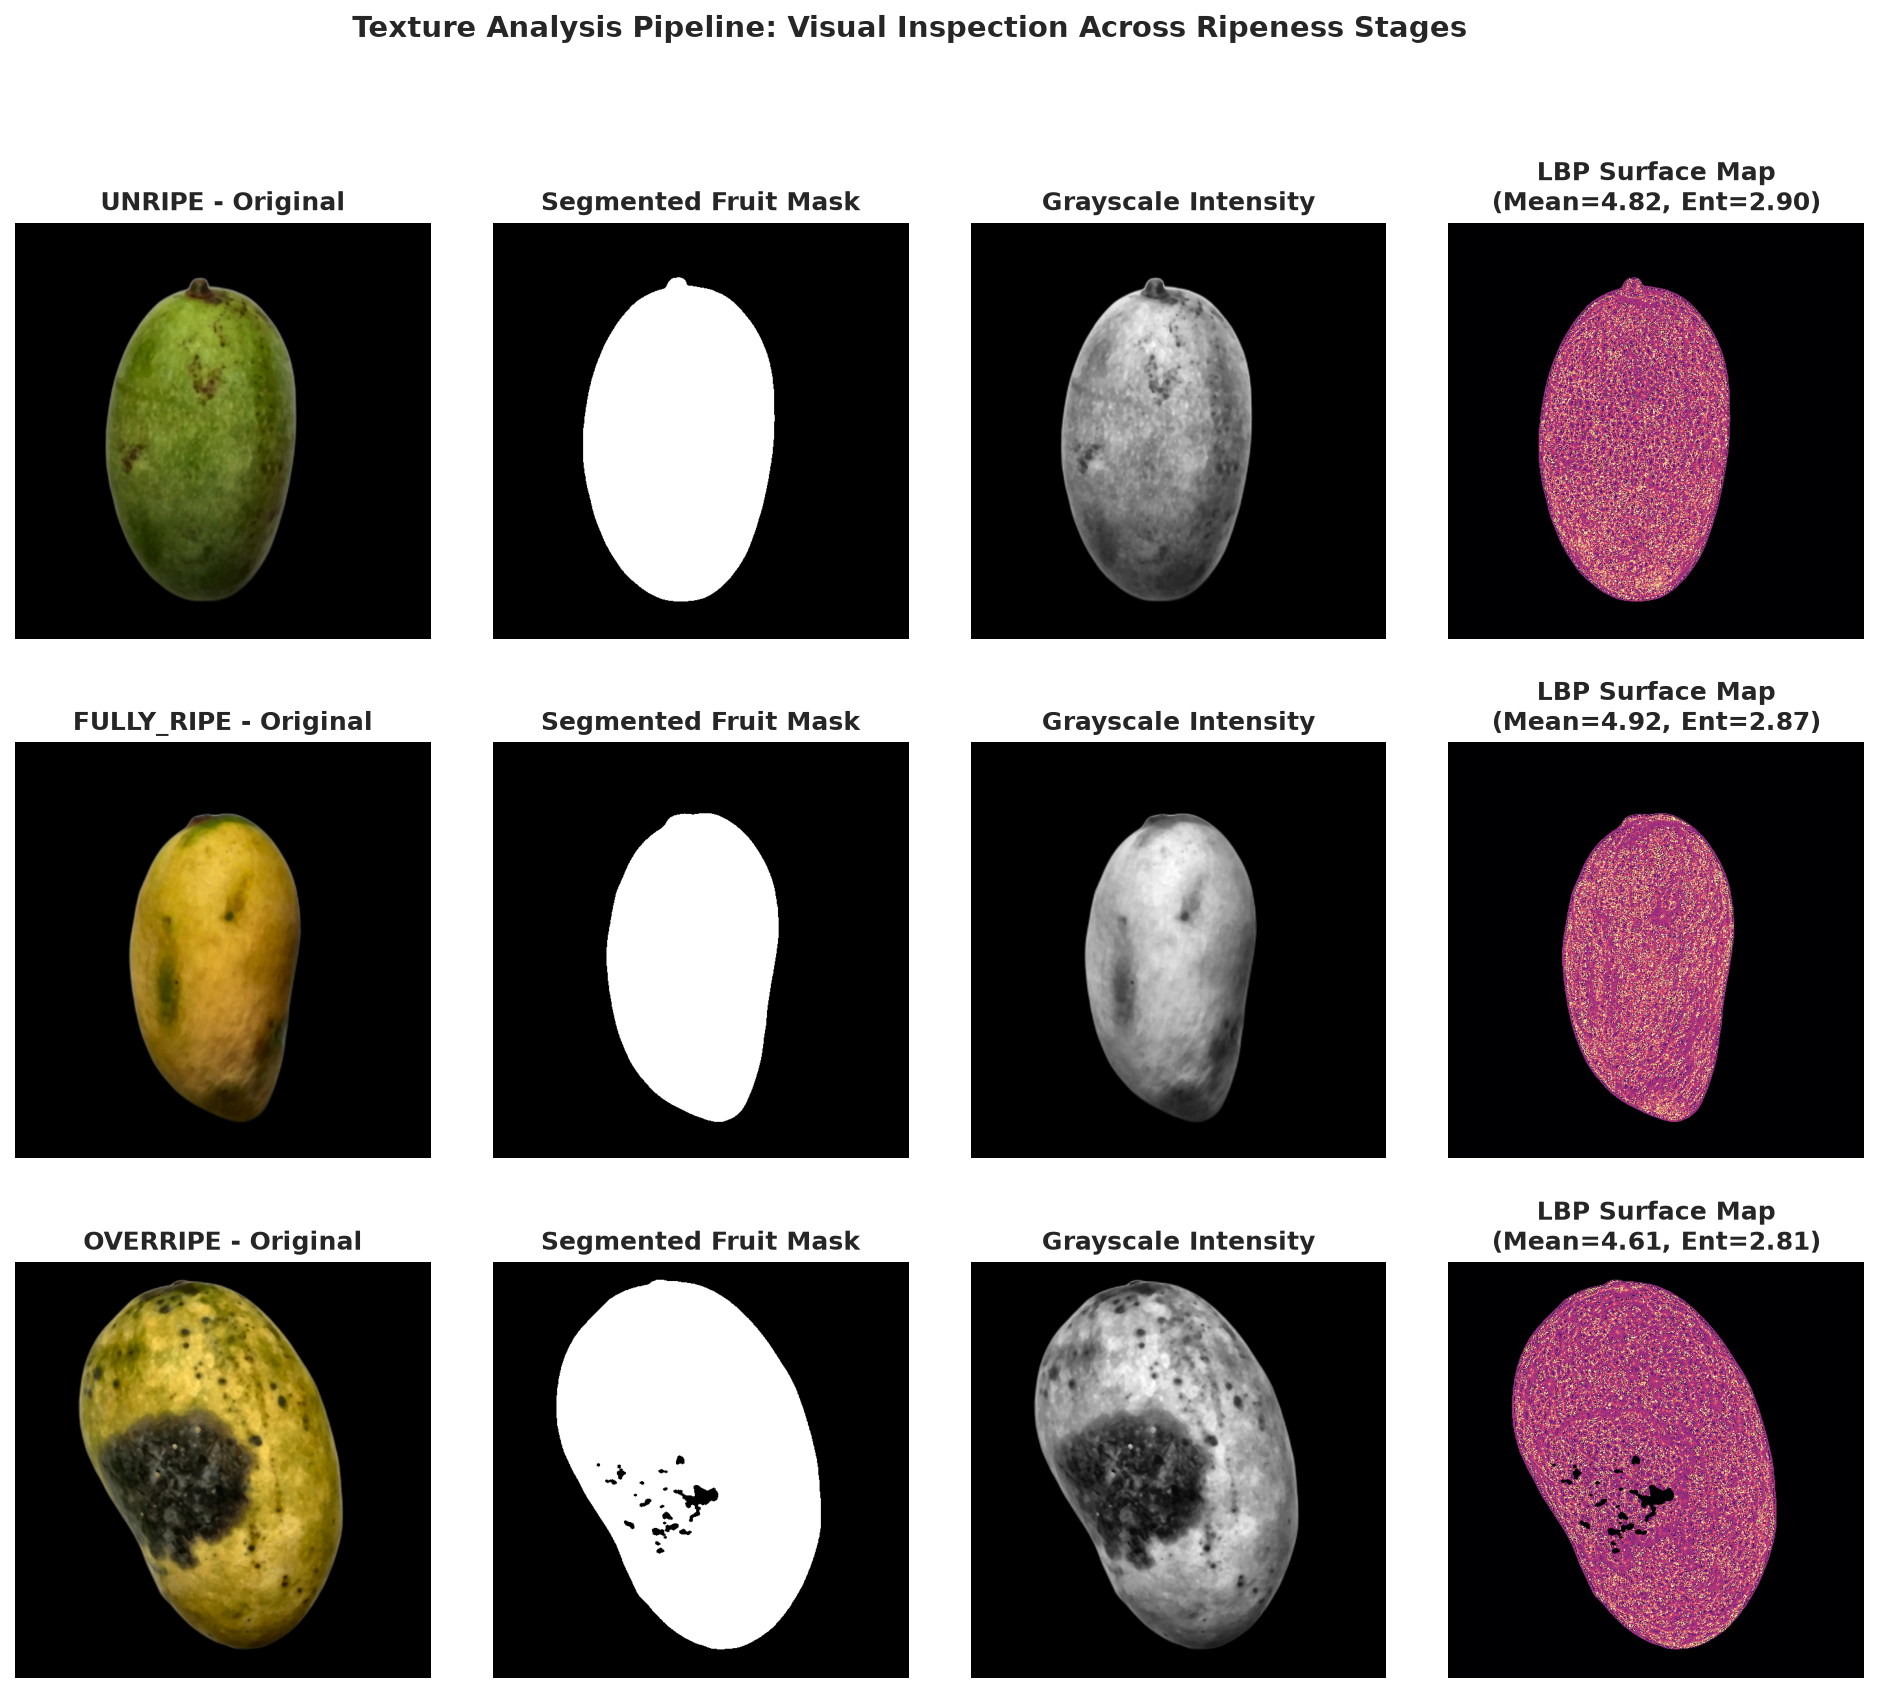

In [4]:
fig, axes = plt.subplots(len(CLASSES), 4, figsize=(16, 4.2 * len(CLASSES)))
plt.subplots_adjust(wspace=0.12, hspace=0.25)

for row, cls in enumerate(CLASSES):
    sample_path = sorted((DATASET_ROOT / 'train' / cls).glob('*.jpg'))[0]
    bgr = cv2.imread(str(sample_path))
    feats, mask, gray, lbp_map = texture_pipeline(bgr)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # 1. Original RGB
    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f"{cls.upper()} - Original", fontweight='bold')
    axes[row, 0].axis('off')

    # 2. Fruit Mask
    axes[row, 1].imshow(mask, cmap='gray')
    axes[row, 1].set_title(f"Segmented Fruit Mask", fontweight='bold')
    axes[row, 1].axis('off')

    # 3. Grayscale
    axes[row, 2].imshow(gray, cmap='gray')
    axes[row, 2].set_title(f"Grayscale Intensity", fontweight='bold')
    axes[row, 2].axis('off')

    # 4. LBP Map
    masked_lbp = np.where(mask > 0, lbp_map, 0)
    axes[row, 3].imshow(masked_lbp, cmap='magma')
    axes[row, 3].set_title(f"LBP Surface Map\n(Mean={feats['lbp_mean']:.2f}, Ent={feats['lbp_entropy']:.2f})", fontweight='bold')
    axes[row, 3].axis('off')

plt.suptitle("Texture Analysis Pipeline: Visual Inspection Across Ripeness Stages", y=0.99, fontsize=14, fontweight='bold')
plt.show()


## 5. [Dataset Extraction] Feature Extraction across Train and Test Datasets
Extracting the 7 standardized texture features across all 715 images and saving structured datasets into `output/texture_based/`.


In [5]:
def build_feature_dataset(split):
    """Extract 7 texture features from every image in cleaned_data/<split>/<class>."""
    rows = []
    for cls in CLASSES:
        folder = DATASET_ROOT / split / cls
        files = sorted(list(folder.glob('*.jpg')) + list(folder.glob('*.png')))
        for p in tqdm(files, desc=f"Extracting texture features [{split} - {cls}]"):
            img = cv2.imread(str(p))
            if img is None:
                continue
            feats, _, _, _ = texture_pipeline(img)
            rows.append({
                'filename': p.name,
                'class': cls,
                'train_or_test': split,
                **feats
            })
    return pd.DataFrame(rows)

print("[Process] Extracting features across Train and Test datasets...")
df_train = build_feature_dataset('train')
df_test  = build_feature_dataset('test')

# Save individual split CSVs and combined CSV (consistent with teammate conventions)
train_csv_path = OUTPUT_DIR / 'texture_train_features.csv'
test_csv_path  = OUTPUT_DIR / 'texture_test_features.csv'
all_csv_path   = OUTPUT_DIR / 'texture_features.csv'

df_train.to_csv(train_csv_path, index=False)
df_test.to_csv(test_csv_path, index=False)

df_all = pd.concat([df_train, df_test], ignore_index=True)
df_all.to_csv(all_csv_path, index=False)

print(f"\n[Storage] Saved: {train_csv_path} ({len(df_train)} rows)")
print(f"[Storage] Saved: {test_csv_path} ({len(df_test)} rows)")
print(f"[Storage] Saved: {all_csv_path} ({len(df_all)} rows)")


[Process] Extracting features across Train and Test datasets...

[Storage] Saved: C:\repository\mango-ripeness-grading\output\texture_based\texture_train_features.csv (571 rows)
[Storage] Saved: C:\repository\mango-ripeness-grading\output\texture_based\texture_test_features.csv (144 rows)
[Storage] Saved: C:\repository\mango-ripeness-grading\output\texture_based\texture_features.csv (715 rows)


Extracting texture features [test - overripe]: 100%|##########| 48/48 [00:03<00:00, 15.43it/s]


## 6. [Feature Distribution Analysis] Feature Statistics and Class Separation Boxplots
Analyzing descriptive statistics and class separability of GLCM and LBP features across ripeness stages.


glcm_contrast         glcm_correlation        glcm_energy        glcm_homogeneity        lbp_mean        lbp_variance        lbp_entropy       
                    mean     std             mean    std        mean    std             mean    std     mean    std         mean    std        mean    std
class                                                                                                                                                     
fully_ripe        38.533   9.113            0.987  0.003       0.029  0.003            0.384  0.026    4.838  0.067        3.954  0.167       2.854  0.040
overripe          51.880  12.205            0.984  0.004       0.024  0.003            0.316  0.031    4.692  0.074        3.805  0.269       2.804  0.066
unripe            34.294   5.830            0.978  0.004       0.031  0.002            0.361  0.019    4.816  0.049        4.193  0.235       2.904  0.042

[Feature Analysis] Texture Feature Statistics (Training Set):


<string>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:13: FutureW

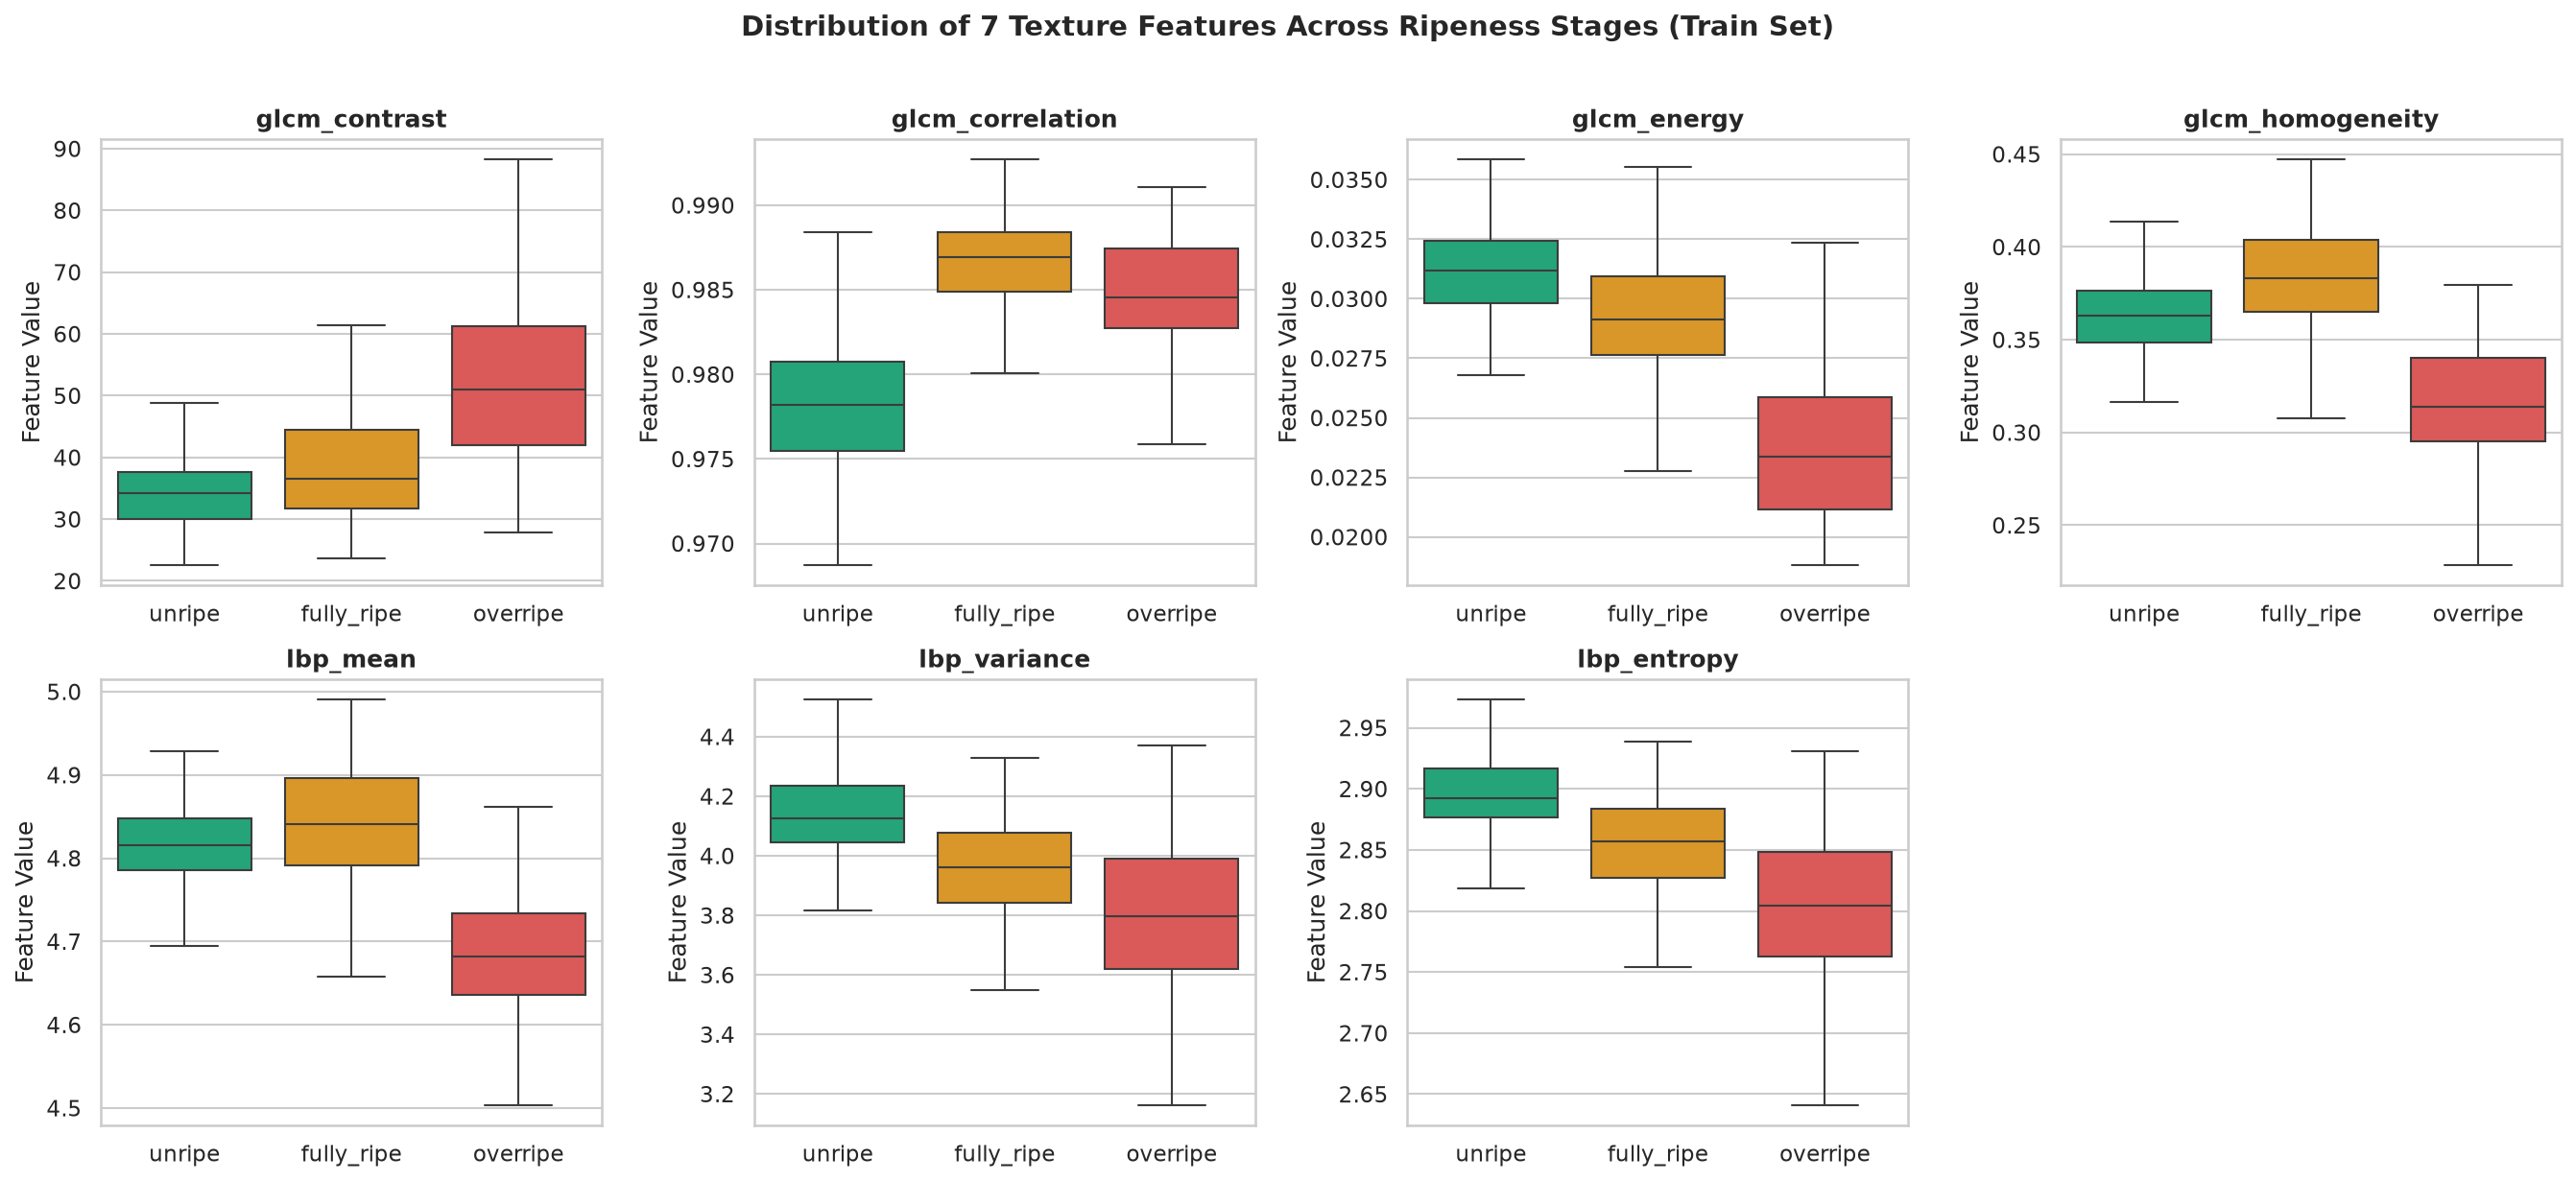

In [6]:
# Feature Descriptive Statistics (Mean ± Std per Ripeness Stage)
stats_table = df_train.groupby('class')[FEATURE_COLS].agg(['mean', 'std']).round(3)
print("[Feature Analysis] Texture Feature Statistics (Training Set):")
display(stats_table)

# 7-Panel Boxplots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

palette = {'unripe': '#10b981', 'fully_ripe': '#f59e0b', 'overripe': '#ef4444'}

for i, col in enumerate(FEATURE_COLS):
    sns.boxplot(data=df_train, x='class', y=col, ax=axes[i], palette=palette, showfliers=False)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Feature Value')

axes[-1].axis('off') # 8th subplot unused (7 features)
plt.suptitle("Distribution of 7 Texture Features Across Ripeness Stages (Train Set)", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. [Model Training & Benchmark Evaluation] Classifier Training & Comparison
Training and quantitatively benchmarking three classical machine learning algorithms on the standardized test set: **Random Forest**, **Support Vector Machine (SVM)**, and **K-Nearest Neighbors (KNN)**.


In [7]:
# Prepare Feature Matrices and Labels
X_train = df_train[FEATURE_COLS].values
y_train = df_train['class'].map(LABEL_MAP).values

X_test = df_test[FEATURE_COLS].values
y_test = df_test['class'].map(LABEL_MAP).values

# Standard Scaling (Fit on Train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Candidate Models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':      SVC(kernel='rbf', probability=True, random_state=42),
    'KNN (k=5)':      KNeighborsClassifier(n_neighbors=5)
}

benchmark_records = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred) * 100.0
    f1 = f1_score(y_test, y_pred, average='macro')

    benchmark_records.append({
        'Classifier': name,
        'Test Accuracy (%)': round(acc, 2),
        'Macro F1-Score': round(f1, 4),
        'Trained Samples': len(X_train),
        'Tested Samples': len(X_test)
    })

df_bench = pd.DataFrame(benchmark_records)
print("=" * 70)
print("[Benchmark Evaluation] Classifier Performance Summary (Test Set):")
print("=" * 70)
print(df_bench.to_string(index=False))

best_idx = df_bench['Test Accuracy (%)'].idxmax()
best_name = df_bench.loc[best_idx, 'Classifier']
best_model = models[best_name]
best_acc = df_bench.loc[best_idx, 'Test Accuracy (%)']
best_f1 = df_bench.loc[best_idx, 'Macro F1-Score']

print(f"\nSelected Best Performing Model: {best_name} (Accuracy: {best_acc}%, Macro F1: {best_f1})")


[Benchmark Evaluation] Classifier Performance Summary (Test Set):
   Classifier  Test Accuracy (%)  Macro F1-Score  Trained Samples  Tested Samples
Random Forest              95.83          0.9582              571             144
    SVM (RBF)              95.83          0.9583              571             144
    KNN (k=5)              96.53          0.9652              571             144

Selected Best Performing Model: KNN (k=5) (Accuracy: 96.53%, Macro F1: 0.9652)


C:\Users\user\AppData\Roaming\Python\Python314\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 8. [Visualization] Confusion Matrix & Feature Importance Ranking
Evaluating class prediction accuracy via confusion matrix heatmap and analyzing feature importance contributions.



[Classification Report for Best Model:]
              precision    recall  f1-score   support

      unripe     1.0000    0.9167    0.9565        48
  fully_ripe     0.9231    1.0000    0.9600        48
    overripe     0.9792    0.9792    0.9792        48

    accuracy                         0.9653       144
   macro avg     0.9674    0.9653    0.9652       144
weighted avg     0.9674    0.9653    0.9652       144



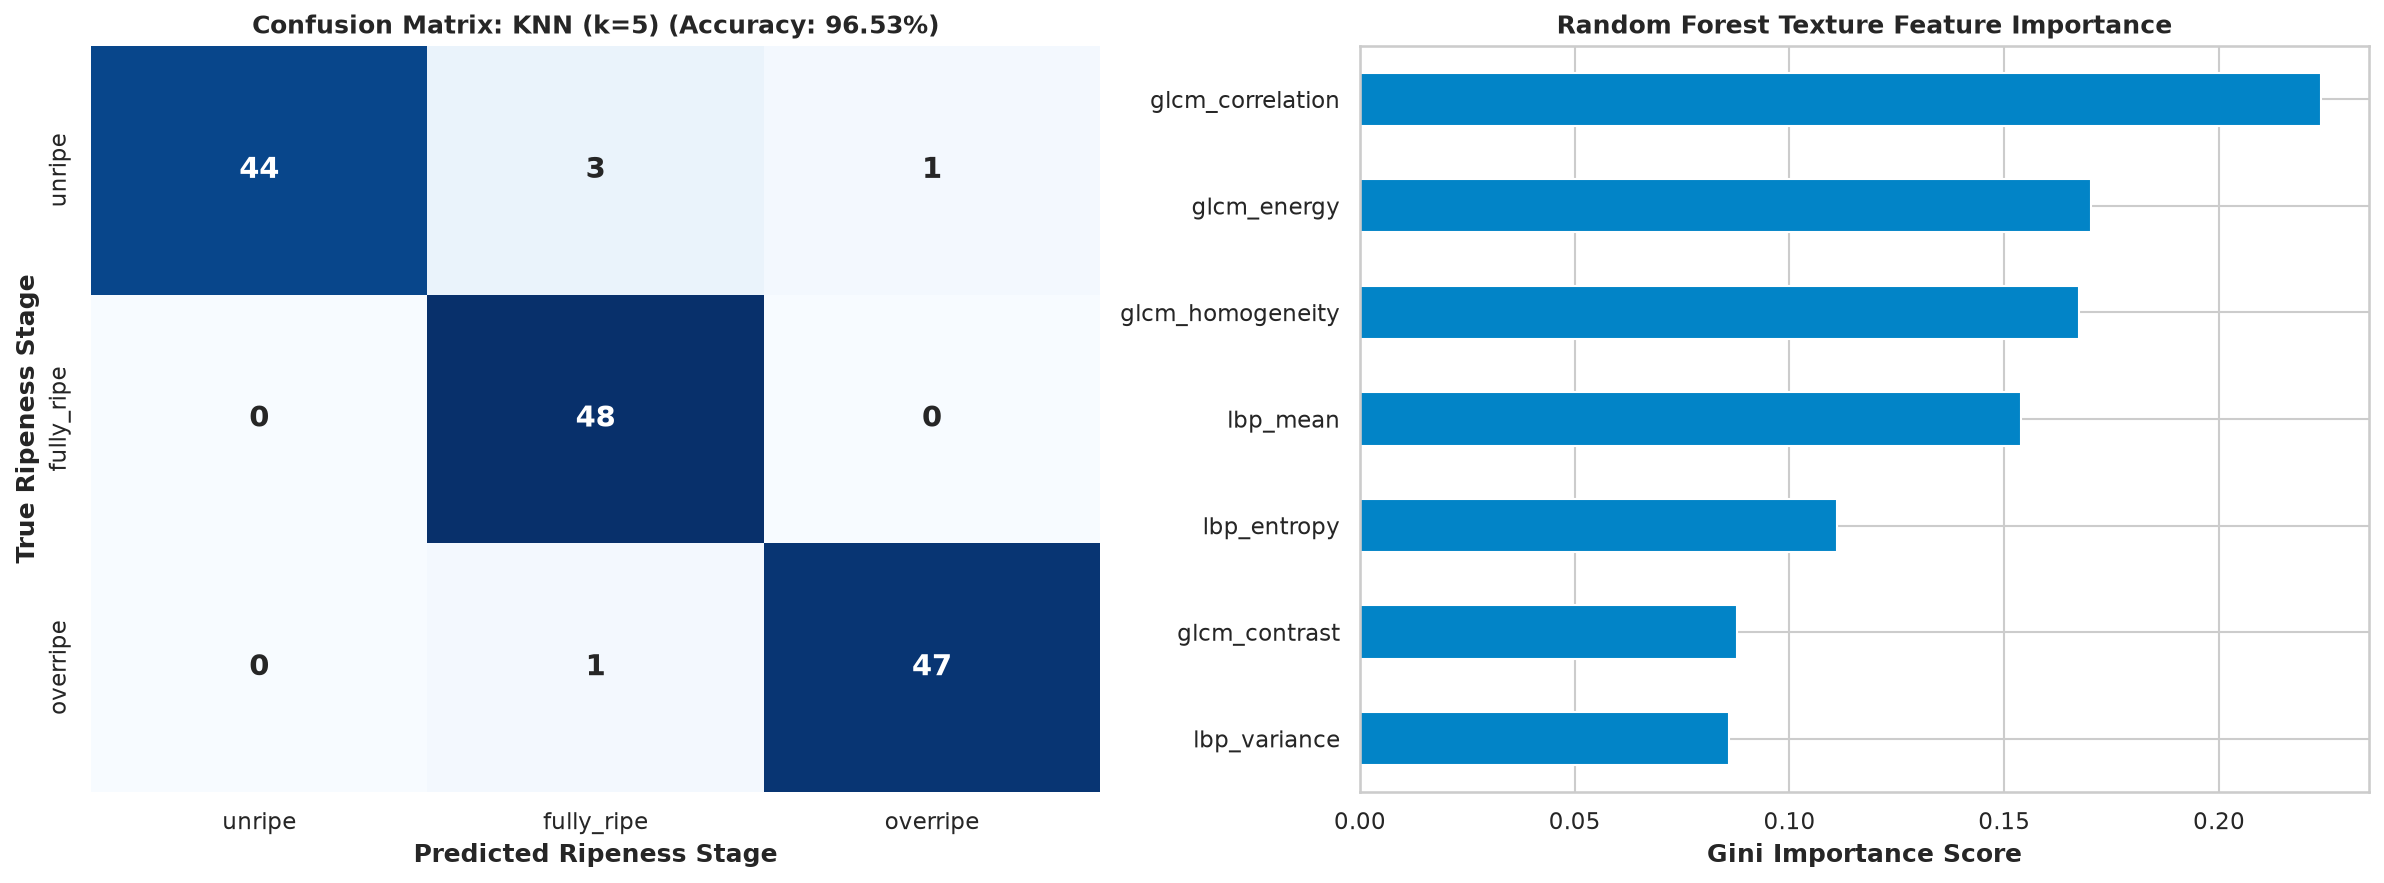

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, predictions[best_name])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASSES, yticklabels=CLASSES,
            cbar=False, annot_kws={'size': 14, 'fontweight': 'bold'})
axes[0].set_title(f"Confusion Matrix: {best_name} (Accuracy: {best_acc}%)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicted Ripeness Stage", fontweight='bold')
axes[0].set_ylabel("True Ripeness Stage", fontweight='bold')

# 2. Random Forest Feature Importance Ranking
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind='barh', color='#0284c7', ax=axes[1])
axes[1].set_title("Random Forest Texture Feature Importance", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Gini Importance Score", fontweight='bold')

plt.tight_layout()
plt.show()

print("\n[Classification Report for Best Model:]")
print(classification_report(y_test, predictions[best_name], target_names=CLASSES, digits=4))


## 9. [Model Export] Serialization for Prototype Deployment
Serializing the trained classifier, fitted scaler, feature metadata, and class mappings to `output/texture_based/texture_model.joblib` for production deployment in `src/texture.py` and `app.py`.


In [9]:
model_package = {
    'model': best_model,
    'scaler': scaler,
    'feature_cols': FEATURE_COLS,
    'classes': CLASSES,
    'label_map': LABEL_MAP,
    'classifier': best_name,
    'test_accuracy': best_acc,
    'macro_f1': best_f1,
    'pipeline_version': 'GLCM_LBP_v1.0'
}

model_save_path = OUTPUT_DIR / 'texture_model.joblib'
joblib.dump(model_package, model_save_path)

print(f"[Model Export] Successfully serialized model package to: {model_save_path}")
print(f"[Model Export] Artifact contains: {list(model_package.keys())}")


[Model Export] Successfully serialized model package to: C:\repository\mango-ripeness-grading\output\texture_based\texture_model.joblib
[Model Export] Artifact contains: ['model', 'scaler', 'feature_cols', 'classes', 'label_map', 'classifier', 'test_accuracy', 'macro_f1', 'pipeline_version']


## 10. [Inference Test] Standalone Single-Image Prediction Pipeline
Simulating the exact standalone inference pipeline used by the Streamlit application.


[Inference Test Verification]:
  - True: unripe      | Predicted: unripe      | Confidence: 80.0% | Latency: 86.2 ms
  - True: fully_ripe  | Predicted: fully_ripe  | Confidence: 100.0% | Latency: 76.1 ms
  - True: overripe    | Predicted: overripe    | Confidence: 100.0% | Latency: 87.6 ms


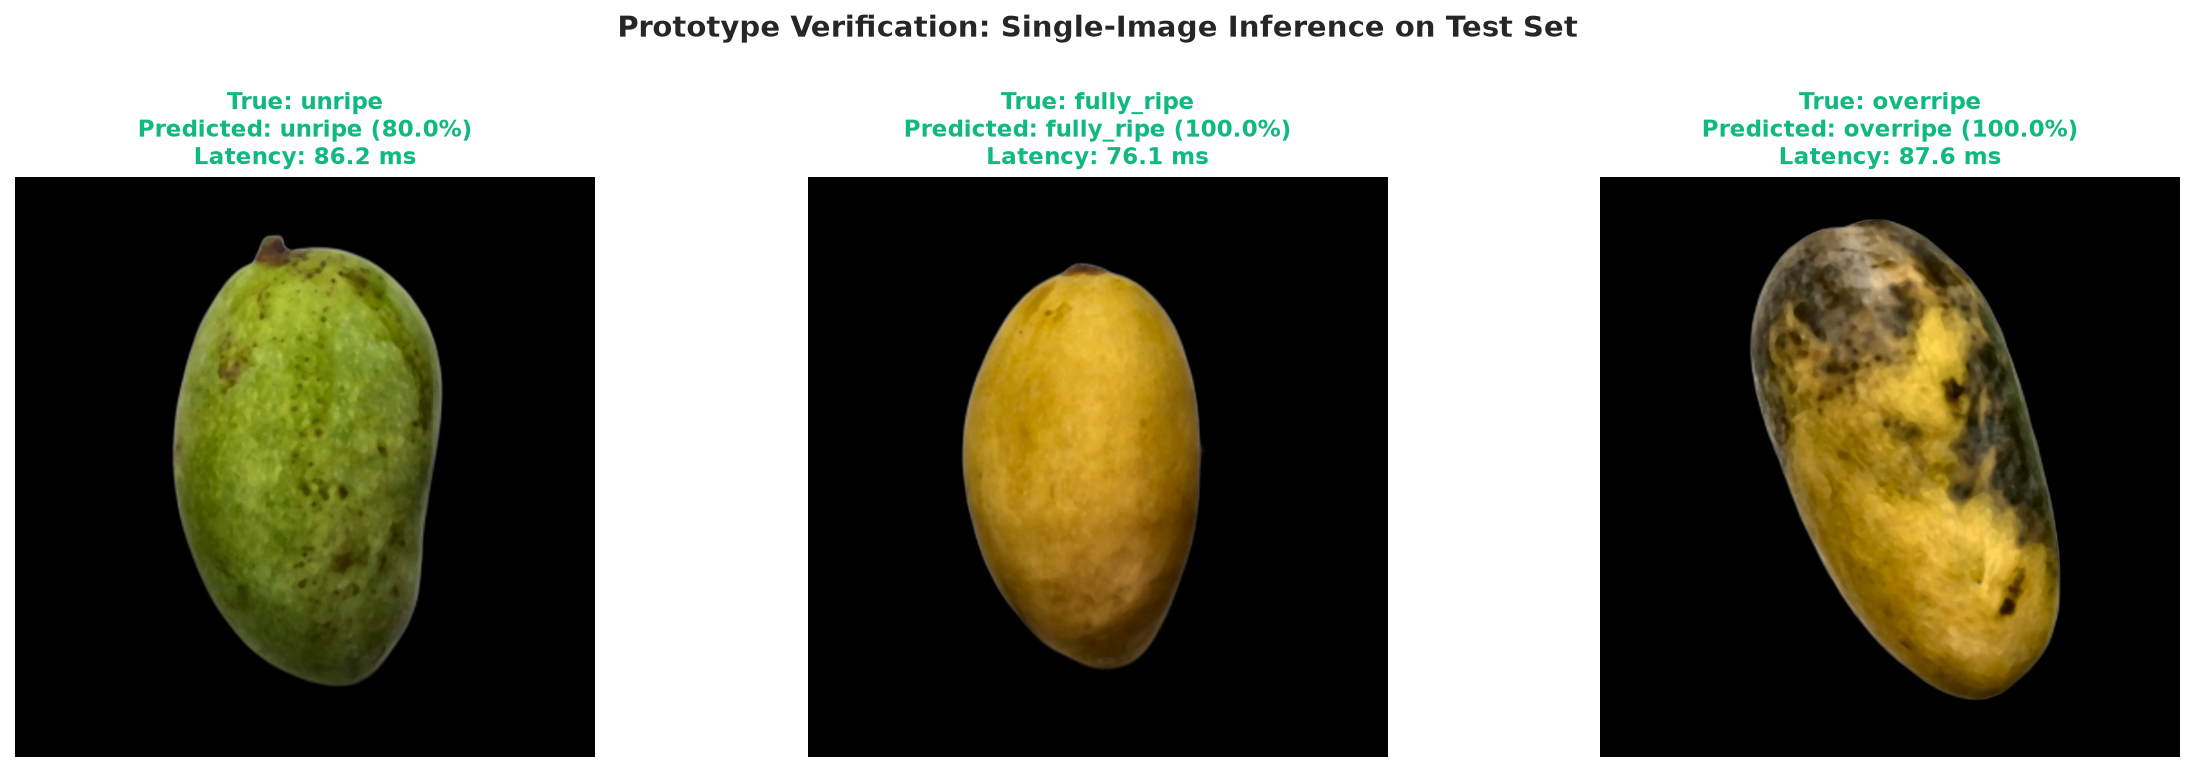

In [10]:
def predict_mango_ripeness(img_path):
    """Full single-image inference: load -> texture features -> scale -> predict."""
    t_start = time.time()
    
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        raise ValueError(f"Could not load image: {img_path}")
        
    pkg = joblib.load(OUTPUT_DIR / 'texture_model.joblib')
    infer_model = pkg['model']
    infer_scaler = pkg['scaler']
    infer_cols = pkg['feature_cols']
    
    feats, mask, gray, lbp_map = texture_pipeline(img_bgr)
    feat_row = pd.DataFrame([feats])[infer_cols].values
    scaled = infer_scaler.transform(feat_row)
    
    pred_label = int(infer_model.predict(scaled)[0])
    pred_class = [c for c, v in LABEL_MAP.items() if v == pred_label][0]
    
    confidence = float('nan')
    if hasattr(infer_model, 'predict_proba'):
        confidence = float(np.max(infer_model.predict_proba(scaled)[0])) * 100.0
        
    elapsed_ms = (time.time() - t_start) * 1000.0
    return {
        'true_class': Path(img_path).parent.name,
        'prediction': pred_class,
        'confidence': confidence,
        'latency_ms': elapsed_ms,
        'image_rgb': cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),
        'features': feats
    }

# Test on one unseen sample from each class
fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 5))
results = []

for ax, cls in zip(axes, CLASSES):
    sample = sorted((DATASET_ROOT / 'test' / cls).glob('*.jpg'))[0]
    res = predict_mango_ripeness(sample)
    results.append((cls, res))
    
    ax.imshow(res['image_rgb'])
    correct = (res['prediction'] == res['true_class'])
    status_color = '#10b981' if correct else '#ef4444'
    ax.set_title(f"True: {res['true_class']}\nPredicted: {res['prediction']} ({res['confidence']:.1f}%)\nLatency: {res['latency_ms']:.1f} ms",
                 fontsize=11, fontweight='bold', color=status_color)
    ax.axis('off')

plt.suptitle("Prototype Verification: Single-Image Inference on Test Set", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("[Inference Test Verification]:")
for true_cls, res in results:
    print(f"  - True: {true_cls:11s} | Predicted: {res['prediction']:11s} | Confidence: {res['confidence']:.1f}% | Latency: {res['latency_ms']:.1f} ms")
